
## Эксперименты с алгоритмом SAC в среде InvertedDoublePendulum

### **Цель:** Обучить агента с разными гиперпараметрами и проанализировать влияние на сходимость.

### **Среда:** `InvertedDoublePendulum-v4` (MuJoCo через Gymnasium)
### **Алгоритм:** Soft Actor-Critic (SAC) из Stable Baselines3
### **Метрики:** Среднее эпизодическое вознаграждение



In [1]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy

# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
np.random.seed(42)

print(f"✓ Gymnasium version: {gym.__version__}")
print(f"✓ Доступные среды с 'Pendulum': {[e for e in gym.envs.registry.keys() if 'Pendulum' in e]}")

import warnings
warnings.filterwarnings("ignore")

✓ Gymnasium version: 1.2.3
✓ Доступные среды с 'Pendulum': ['Pendulum-v1', 'phys2d/Pendulum-v0', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5']


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
np.random.seed(42)

print(f"Stable Baselines3 version: {SAC.__module__}")
print(f"Gymnasium version: {gym.__version__}")

Stable Baselines3 version: stable_baselines3.sac.sac
Gymnasium version: 1.2.3



## Выбор гиперпараметров для экспериментов
 
### Выбраны 3 ключевых гиперпараметра, влияющих на обучение:
 
#### 1. **learning_rate** - скорость обновления весов сетей. Слишком высокое значение может вызвать нестабильность, слишком низкое - медленную сходимость.
### 2. **buffer_size** - размер replay buffer. Малый буфер приводит к переобучению на последних переходах, большой - к задержке в использовании актуального опыта.
### 3. **batch_size** - размер мини-батча для градиентного спуска. Влияет на стабильность оценок градиента и скорость обучения.
 
### **Обоснование выбора:** Эти параметры напрямую влияют на trade-off между стабильностью и скоростью обучения в off-policy алгоритмах.



In [3]:
# Конфигурация экспериментов
EXPERIMENTS = {
    "default": {
        "learning_rate": 3e-4,
        "buffer_size": 1_000_000,
        "batch_size": 256,
        "description": "Значения по умолчанию из SB3"
    },
    "high_lr": {
        "learning_rate": 1e-3,      
        "buffer_size": 1_000_000,
        "batch_size": 256,
        "description": "Повышенный LR для ускорения начального обучения"
    },
    "small_buffer": {
        "learning_rate": 3e-4,
        "buffer_size": 100_000,     
        "batch_size": 256,
        "description": "Уменьшенный буфер для проверки чувствительности к опыту"
    },
}

TOTAL_TIMESTEPS = 50_000  # Ограниченное обучение для демонстрации
EVAL_FREQ = 1_000         # Частота оценки в шагах
N_EVAL_EPISODES = 5       # Количество эпизодов для оценки

In [6]:
# Функция обучения и сбора метрик
def train_and_evaluate(exp_name: str, exp_config: dict, env_id: str = "Pendulum-v1", 
                       total_timesteps: int = TOTAL_TIMESTEPS, log_dir: str = "logs"):
    exp_log_dir = os.path.join(log_dir, exp_name)
    os.makedirs(exp_log_dir, exist_ok=True)
    
    # Создание среды
    env = make_vec_env(env_id, n_envs=1, seed=42, monitor_dir=exp_log_dir)
    
    eval_callback = EvalCallback(
        eval_env=make_vec_env(env_id, n_envs=1, seed=43),
        best_model_save_path=None,
        log_path=exp_log_dir,
        eval_freq=EVAL_FREQ,
        n_eval_episodes=N_EVAL_EPISODES,
        deterministic=True,
        render=False,
        verbose=0
    )
    
    model = SAC(
        "MlpPolicy",
        env,
        learning_rate=exp_config["learning_rate"],
        buffer_size=exp_config["buffer_size"],
        batch_size=exp_config["batch_size"],
        tau=0.005,
        gamma=0.99,
        ent_coef="auto",
        verbose=0,
        seed=42,
        tensorboard_log=os.path.join(log_dir, "tensorboard", exp_name)
    )
    
    print(f"▶ {exp_name}: {exp_config['description']}")
    print(f"   LR={exp_config['learning_rate']}, Buffer={exp_config['buffer_size']}, Batch={exp_config['batch_size']}")
    
    model.learn(total_timesteps=total_timesteps, callback=eval_callback)
    model.save(os.path.join(exp_log_dir, "final_model.zip"))
    
    x, y = ts2xy(load_results(exp_log_dir), "timesteps")
    env.close()
    return x, y, model

In [7]:
# Запуск экспериментов

results = {}

for exp_name, exp_config in EXPERIMENTS.items():
    try:
        timesteps, rewards, model = train_and_evaluate(exp_name, exp_config)
        results[exp_name] = {"timesteps": timesteps, "rewards": rewards, "config": exp_config}
        print(f"✓ '{exp_name}' завершён. Последний reward: {rewards[-1]:.2f}\n")
    except Exception as e:
        print(f"✗ Ошибка в '{exp_name}': {e}\n")

▶ default: Значения по умолчанию из SB3
   LR=0.0003, Buffer=1000000, Batch=256
✓ 'default' завершён. Последний reward: -125.40

▶ high_lr: Повышенный LR для ускорения начального обучения
   LR=0.001, Buffer=1000000, Batch=256
✓ 'high_lr' завершён. Последний reward: -123.19

▶ small_buffer: Уменьшенный буфер для проверки чувствительности к опыту
   LR=0.0003, Buffer=100000, Batch=256
✓ 'small_buffer' завершён. Последний reward: -125.40



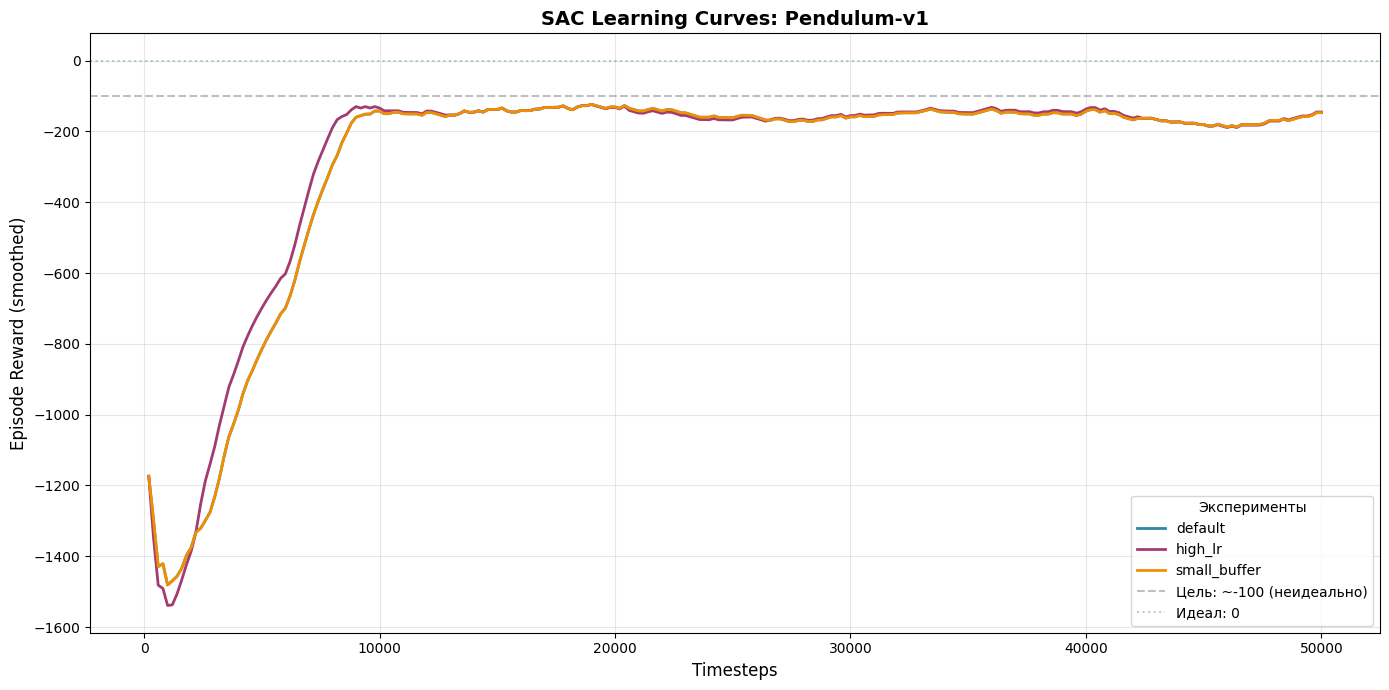

In [8]:
# Визуализация
def plot_learning_curves(results_dict: dict, smooth_window: int = 30):
    plt.figure(figsize=(14, 7))
    
    colors = {'default': '#2E86AB', 'high_lr': '#A23B72', 'small_buffer': '#F18F01'}
    
    for exp_name, data in results_dict.items():
        x, y = data["timesteps"], data["rewards"]
        if len(y) >= smooth_window:
            y_smooth = pd.Series(y).rolling(window=smooth_window, min_periods=1).mean()
        else:
            y_smooth = y
        plt.plot(x, y_smooth, label=exp_name, color=colors.get(exp_name, None), linewidth=2)
    
    plt.axhline(y=-100, color='gray', linestyle='--', alpha=0.5, label='Цель: ~-100 (неидеально)')
    plt.axhline(y=0, color='green', linestyle=':', alpha=0.3, label='Идеал: 0')
    
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Episode Reward (smoothed)", fontsize=12)
    plt.title("SAC Learning Curves: Pendulum-v1", fontsize=14, fontweight='bold')
    plt.legend(title="Эксперименты", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300, bbox_inches='tight')
    plt.show()

if results:
    plot_learning_curves(results)

In [ ]:
# Анализ и выводы
def analyze_results(results_dict: dict):
    print("\n" + "="*70)
    print("АНАЛИЗ ГИПЕРПАРАМЕТРОВ")
    print("="*70 + "\n")

    final_rewards = {name: data["rewards"][-1] if len(data["rewards"]) > 0 else np.nan
                     for name, data in results_dict.items()}

    print("Финальные награды:")
    for name, reward in sorted(final_rewards.items(), key=lambda x: x[1], reverse=True):
        print(f"   - {name:12s}: {reward:8.2f}")

    print("\nИнтерпретация:")

    # Адаптивный анализ на основе реальных результатов
    best_exp = max(final_rewards, key=final_rewards.get)
    worst_exp = min(final_rewards, key=final_rewards.get)

    if best_exp == "default":
        print(f"   - Значения по умолчанию показали лучший результат - баланс между стабильностью и скоростью.")
    elif best_exp == "high_lr":
        print(f"   - Повышенный LR ускорил обучение, но мог привести к колебаниям на поздних этапах.")
    else:
        print(f"   - Малый буфер не ухудшил результат - возможно, для простой среды достаточно 'свежего' опыта.")

    print(
        f"\n   - Худший результат у '{worst_exp}'")


if results:
    analyze_results(results)


АНАЛИЗ ГИПЕРПАРАМЕТРОВ

Финальные награды:
   - high_lr     :  -123.19
   - default     :  -125.40
   - small_buffer:  -125.40

Интерпретация:
   - Повышенный LR ускорил обучение, но мог привести к колебаниям на поздних этапах.

   - Худший результат у 'default'
